In [58]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random

In [59]:
random.seed(4354678)

In [2]:
img_list = os.listdir("../dataset/one_revoc/img")

In [32]:
!ls ../dataset/

obj  obj_mask  one_revoc  one_revoc_original  one_revoc_png


In [30]:
mask_dir = "../../VOCdevkit/VOC2012/SegmentationObject/"
dest_dir = "../dataset/obj_mask/"
img_dir = "../dataset/one_revoc/img/"
obj_dir = "../dataset/obj/"

In [22]:
# Create whitemask
for img in img_list:
    mask = cv2.imread(os.path.join(mask_dir,img.split(".")[0]+".png"))
    final_name = dest_dir + img.split(".")[0]+".png"
    target = white_pixels = np.where(
    (mask[:, :, 0] != 0) |
    (mask[:, :, 1] != 0) |
    (mask[:, :, 2] != 0)
    )
    mask[target] = [255] * 3
    cv2.imwrite(final_name, mask, [int(cv2.IMWRITE_JPEG_QUALITY), 100])

img_shape (375, 500, 3)
mask_shape (375, 500)
img_shape (337, 500, 3)
mask_shape (337, 500)
img_shape (375, 500, 3)
mask_shape (375, 500)
img_shape (332, 500, 3)
mask_shape (332, 500)
img_shape (367, 500, 3)
mask_shape (367, 500)
img_shape (333, 500, 3)
mask_shape (333, 500)
img_shape (332, 500, 3)
mask_shape (332, 500)
img_shape (375, 500, 3)
mask_shape (375, 500)
img_shape (375, 500, 3)
mask_shape (375, 500)
img_shape (500, 375, 3)
mask_shape (500, 375)
img_shape (375, 500, 3)
mask_shape (375, 500)
img_shape (500, 375, 3)
mask_shape (500, 375)
img_shape (327, 500, 3)
mask_shape (327, 500)
img_shape (375, 500, 3)
mask_shape (375, 500)
img_shape (375, 500, 3)
mask_shape (375, 500)
img_shape (330, 500, 3)
mask_shape (330, 500)
img_shape (333, 500, 3)
mask_shape (333, 500)
img_shape (400, 500, 3)
mask_shape (400, 500)
img_shape (333, 500, 3)
mask_shape (333, 500)
img_shape (375, 500, 3)
mask_shape (375, 500)
img_shape (332, 500, 3)
mask_shape (332, 500)
img_shape (375, 500, 3)
mask_shape

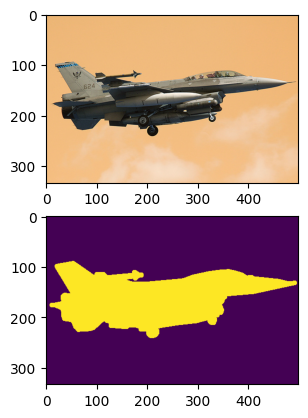

In [37]:
for fn in img_list:
    fn_png = fn.split(".")[0] + ".png"
    img = cv2.imread("../dataset/one_revoc_original/img/" + fn)
    plt.subplot(2,1,1)
    plt.imshow(img)
    print(f"img_shape {img.shape}")
    mask = cv2.imread(dest_dir + fn_png)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    plt.subplot(2,1,2)
    plt.imshow(mask)
    print(f"mask_shape {mask.shape}")
    m+d_img = cv2.bitwise_and(img,img,mask=mask)
    cv2.imwrite(obj_dir+fn_png, masked_img)
    

In [38]:
mask_list = os.listdir("../dataset/obj/")

In [45]:
!mkdir ../dataset/

In [46]:
output_dir = "../dataset/tmp"

(375, 500, 3)


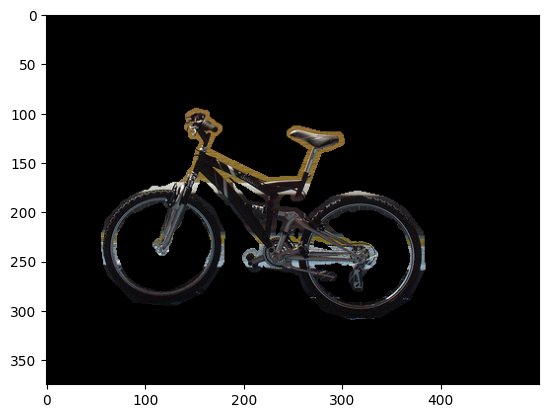

In [51]:
test_fn =mask_list[0]
test_img = cv2.imread("../dataset/obj/"+test_fn)
plt.imshow(test_img)
print(test_img.shape)

In [53]:
for fn in mask_list:
    mask = cv2.imread("../dataset/obj/" + fn)
    bottom = 500 - mask.shape[0]
    right = 500 - mask.shape[1]
    mask = cv2.copyMakeBorder(mask, top=0, bottom=bottom, left=0, right=right,borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    cv2.imwrite("../dataset/tmp/"+fn,mask)

In [81]:
for fn in mask_list:
    # Suppose your image is already read as BGR
    img = cv2.imread("../dataset/tmp/"+fn)
    
    # Convert to grayscale if it's colored
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Create a binary mask of the object (object = 1, background = 0)
    mask = gray > 0
    ys, xs = np.where(mask)
    h, w = mask.shape
    top_dist = ys.min()                 # distance from top border
    bottom_dist = h - 1 - ys.max()      # distance from bottom border
    left_dist = xs.min()                # distance from left border
    right_dist = w - 1 - xs.max()       # distance from right border
    
    #mask = np.concatenate(mask[ys.min():],mask[:ys.min()])
    img = np.vstack((img[ys.min():],img[:ys.min()]))
    cut = xs.min() - 1
    left = img[:, :cut]
    right = img[:, cut:]
    img = np.hstack((right, left))
    #plt.imshow(img)
    cv2.imwrite("../dataset/obj_norm/"+fn,img)
    